In [17]:
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
from torch.utils.data import DataLoader
from dl_project import *

device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
# UNet building blocks
class ResBlock(nn.Module):
    def __init__(self, num_channels, time_embedding_dim, dropout_rate=0.5):
        super().__init__()
        self.relu = nn.ReLU()
        # ! only use primitives (batchnorm, conv2d, dropout)
        self.norm1 = nn.BatchNorm2d(num_features=num_channels)
        self.norm2 = nn.BatchNorm2d(num_features=num_channels)
        self.conv1 = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_rate)
        # project time embedding to desired channel dimension,
        # since each resblock requires an embedding of the same dimension as the input
        # todo fix time embed dim => should match x dim
        self.time_mlp = nn.Linear(time_embedding_dim, num_channels)

    def forward(self, x, time_embedding):
        x = x + self.time_mlp(time_embedding).unsqueeze(-1).unsqueeze(-1)
        residual = x
        x = self.conv1(self.relu(self.norm1(x)))
        x = self.dropout(x)
        x = self.conv2(self.relu(self.norm2(x)))
        return x + residual


class AttentionBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, dropout_rate=0.5):
        super().__init__()
        # copied from assignment 3 and modified
        self.num_heads = num_heads  # Number of attention heads
        self.embedding_dim = embedding_dim  # Embedding dimensionality

        # Maps embedding into Q, K, V. We'll use one layer to generate these matrices for all heads at once.
        self.qkv_map = nn.Linear(embedding_dim, 3 * embedding_dim)

        # After performing attention for each head individually, we concat the results
        # and feed them through this linear layer.
        self.final_projection = nn.Linear(embedding_dim, embedding_dim)
        self.final_dropout = nn.Dropout(dropout_rate)  # regularization

    # todo simplify reshaping procedure
    def forward(self, x):
        x = x.flatten(2, 3).permute(0, 2, 1)  # reshape image to sequence (B, C, H, W) => (B, T, C)
        B, T, C = x.shape  # B: batch size, T: sequence length, C: embedding dimension
        d_k = C // self.num_heads  # dimension of q/k/v vectors

        # compute queries, keys, values with a single projection, split up and reshape
        qkv = self.qkv_map(x)
        Q, K, V = torch.chunk(qkv, 3, dim=-1)
        Q = Q.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        K = K.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        V = V.reshape(B, T, self.num_heads, d_k).transpose(1, 2)

        for M in [Q, K, V]:
            assert M.shape == (
                B,
                self.num_heads,
                T,
                d_k,
            ), f"Expected shape (B, self.n_head, T, d_k), but got {M.shape}"

        # compute similarity between queries and keys
        # compute attention weights based on similarity
        # update embeddings with weighted values
        S = Q @ K.transpose(-2, -1) / np.sqrt(d_k)
        A = F.softmax(S, dim=-1)
        out = A @ V

        # rearrange back to (B, T, C)
        out = out.transpose(1, 2).reshape(B, T, C)
        out = self.final_dropout(self.final_projection(out))
        return out


# 2 ResBlocks with an optional AttentionBlock in between followed by a final Up/Downsampling block
class UNetLayer(nn.Module):
    def __init__(self, type, num_channels, time_embedding_dim, num_heads=0):
        super().__init__()
        self.type = type
        self.res1 = ResBlock(num_channels, time_embedding_dim)
        self.res2 = ResBlock(num_channels, time_embedding_dim)
        self.num_heads = num_heads
        if num_heads:
            self.attention = AttentionBlock(num_channels, num_heads=num_heads)

        # todo check up down logic
        if type == "down":
            self.conv = nn.Conv2d(num_channels, num_channels * 2, kernel_size=3, stride=2, padding=1)
        elif type == "up":
            self.conv = nn.ConvTranspose2d(
                num_channels, num_channels // 2, kernel_size=3, stride=2, padding=1, output_padding=1
            )
        else:
            raise ValueError(f"Unknown layer type: {type}")

    def forward(self, x, time_embeddings):
        x = self.res1(x, time_embeddings)
        # if self.num_heads:
        #     x = self.attention(x)
        x = self.res2(x, time_embeddings)
        if self.type == "down":
            return self.conv(x), x  # downsampled version + residual
        return self.conv(x)  # upsampled versions

In [19]:
# generate time embeddings for UNet using a MLP
# todo experiment with sinusoidal embeddings and other methods
class MLPTimeEmbedding(nn.Module):
    def __init__(self, T, embedding_dim):
        super().__init__()
        self.T = T
        self.mlp = nn.Sequential(
            nn.Linear(1, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, t):
        assert 0 <= t <= self.T, f"Time index t must be in [0, {self.T}]"
        t = t / self.T  # normalize to [0, 1]
        t = torch.tensor([[t]])
        return self.mlp(t)

In [20]:
class UNet(nn.Module):
    def __init__(self, T, depth=3, initial_channels=64, time_embedding_dim=128, color_spectrum=3):
        super(UNet, self).__init__()

        # dynamic channel calculation based on depth
        # downsampling reduces the image size by a factor of 2 but doubles the number of channels
        down_channels = []
        for i in range(depth):
            down_channels.append(initial_channels * (2**i))

        # upsampling halves the number of channels but doubles the image size
        up_channels = [down_channels[-1] * 2]  # bottleneck without skip connection
        for i in range(depth - 1, 0, -1):
            up_channels.append(down_channels[i] + up_channels[-1] // 2)
        final_channels = up_channels[-1] // 2 + down_channels[0]

        # initial convolution to map input to desired number of initial channels
        self.conv1 = nn.Conv2d(color_spectrum, down_channels[0], kernel_size=3, padding=1)

        # downsampling layers + bottleneck + upsampling layers
        self.down1 = UNetLayer("down", down_channels[0], time_embedding_dim)
        self.down2 = UNetLayer("down", down_channels[1], time_embedding_dim, num_heads=8)
        self.down3 = UNetLayer("down", down_channels[2], time_embedding_dim)
        self.bottleneck = UNetLayer("up", up_channels[0], time_embedding_dim)
        self.up1 = UNetLayer("up", up_channels[1], time_embedding_dim)
        self.up2 = UNetLayer("up", up_channels[2], time_embedding_dim, num_heads=8)

        # convolution to half the number of channels
        self.conv2 = nn.Conv2d(final_channels, final_channels // 2, kernel_size=3, padding=1)
        # final layer to map back to RGB
        self.conv3 = nn.Conv2d(final_channels // 2, color_spectrum, kernel_size=3, padding=1)

        self.activation = nn.ReLU()
        self.time_embedding = MLPTimeEmbedding(T, time_embedding_dim)

    def forward(self, x, t):
        time_embedding = self.time_embedding(t)
        x = self.activation(self.conv1(x))

        # downsample and store intermediates for skip connections
        x, r1 = self.down1(x, time_embedding)
        x, r2 = self.down2(x, time_embedding)
        x, r3 = self.down3(x, time_embedding)

        # bottleneck without skip connection
        x = self.bottleneck(x, time_embedding)

        # upsample and concatenate skip connections
        x = torch.cat([x, r3], dim=1)
        x = self.up1(x, time_embedding)
        x = torch.cat([x, r2], dim=1)
        x = self.up2(x, time_embedding)
        x = torch.cat([x, r1], dim=1)

        # final convolutions back to RGB
        x = self.activation(self.conv2(x))
        x = self.conv3(x)
        return x

In [21]:
class Schedule:
    def __init__(self, beta_1, beta_T, T, type="linear"):
        assert 0 < beta_1 < beta_T < 1, f"Invalid beta values: {beta_1}, {beta_T}"
        if type == "linear":
            beta_t = torch.linspace(beta_1, beta_T, T)
            self.alpha_t = 1 - beta_t
        elif type == "cosine":
            # ? is this correct?
            t = torch.linspace(0, T, T)
            self.alpha_t = torch.cos(t * (np.pi / 2 / T)) ** 2
        else:
            raise ValueError(f"Unknown schedule type: {type}")

        self.T = T
        self.alpha_bar_t = torch.cumprod(self.alpha_t, 0)  # product of all elements in alpha_t from 1 to t
        self.sqrt_alpha_bar_t = torch.sqrt(self.alpha_bar_t)  # first term of noise equation
        self.sqrt_1_minus_alpha_bar_t = torch.sqrt(1 - self.alpha_bar_t)  # second term of noise equation
        self.one_over_sqrt_alpha_t = 1 / torch.sqrt(self.alpha_t)  # first term of sampling equation
        self.beta_t_over_sqrt_1_minus_alpha_bar_t = (
            beta_t / self.sqrt_1_minus_alpha_bar_t
        )  # second term of sampling equation


# typical values
T = 1000
beta_1 = 0.0001
beta_T = 0.02

In [22]:
class DDPM(nn.Module):
    sigma_t_constant = {"strategy": "constant", "constant": 0.05}
    sigma_t_linear = {"strategy": "linear", "min": 0.01, "max": 0.1}
    sigma_t_cosine = {"strategy": "cosine", "min": 0.01, "max": 0.1}

    # todo handle device and dtype
    # todo experiment with torch.compile
    def __init__(self, schedule, sigma_t_strategy=sigma_t_constant):  # todo add parameters
        super(DDPM, self).__init__()
        self.schedule = schedule
        self.noise_predictor = UNet(schedule.T)  # predicts noise given a noisy image and a time index
        self.sigma_t_strategy = sigma_t_strategy  # strategy for noise generation which is added back during sampling

    # adds noise to the input image
    def forward_diffusion(self, x, t):
        epsilon = torch.randn(x.shape)  # noise
        alpha_bar_t = self.schedule.alpha_bar_t[t]
        sqrt__1_minus_alpha_bar_t = self.schedule.sqrt_1_minus_alpha_bar_t[t]
        return alpha_bar_t * x + sqrt__1_minus_alpha_bar_t * epsilon, epsilon

    # generates images from noise
    def generate_images(self, shape, num_images=1):
        # shape: (C, H, W)
        # H, W are arbitrary but should be equal to training shape for best results
        shape = (num_images, *shape)  # generate a batch of images
        x_t = torch.randn(shape)  # complete random noise
        one_over_sqrt_alpha_t = self.schedule.one_over_sqrt_alpha_t
        beta_t_over_sqrt_1_minus_alpha_bar_t = self.schedule.beta_t_over_sqrt_1_minus_alpha_bar_t

        for t in reversed(range(self.schedule.T)):
            # predict variance of noise and remove the noise from the image
            prediction = self.noise_predictor(x_t, t)
            x_t = one_over_sqrt_alpha_t[t] * (x_t - beta_t_over_sqrt_1_minus_alpha_bar_t[t] * prediction)

            # return final image x_0 without adding noise
            if t == 0:
                return x_t

            # add a little noise back
            x_t += self.__get_sigma_t__(t) * torch.randn(shape)

    def __get_sigma_t__(self, t):
        strategy = self.sigma_t_strategy["strategy"]
        if strategy == "constant":
            return self.sigma_t_strategy["constant"]

        sigma_min = self.sigma_t_strategy["min"]
        sigma_max = self.sigma_t_strategy["max"]
        if strategy == "linear":
            return sigma_min + (sigma_max - sigma_min) * (t / self.schedule.T)
        elif strategy == "cosine":
            return (1 - np.cos(t * np.pi / self.schedule.T)) / 2 * (sigma_max - sigma_min) + sigma_min
        raise ValueError(f"Unknown noise generation strategy: {strategy}")

    def train(self, data_loader, epochs=100):
        # todo
        pass

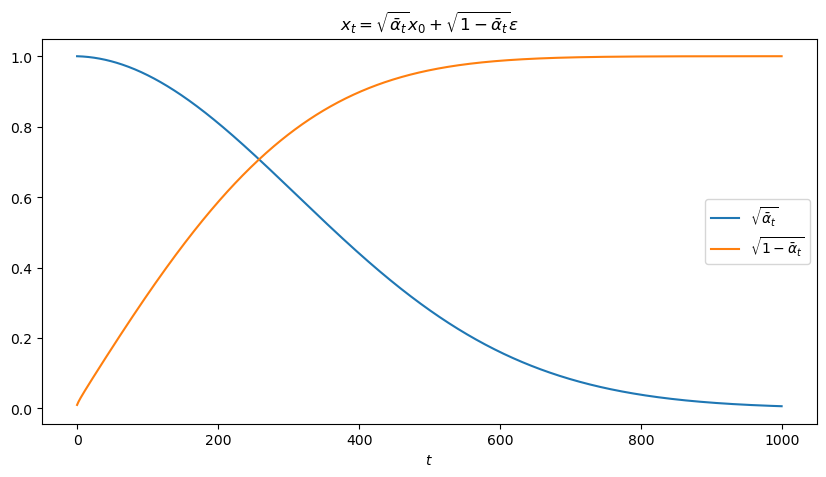

In [23]:
# test schedules by comparing it with the example in P12.ipynb
schedule = Schedule(1e-4, 0.02, 1000)
sqrt_alpha_bar = schedule.sqrt_alpha_bar_t
sqrt_one_minus_alpha_bar = schedule.sqrt_1_minus_alpha_bar_t

plt.figure(figsize=(10, 5))
plt.title(r"$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$")
plt.xlabel("$t$")
plt.plot(sqrt_alpha_bar, label=r"$\sqrt{\bar{\alpha}_t}$")
plt.plot(sqrt_one_minus_alpha_bar, label=r"$\sqrt{1-\bar{\alpha}_t}$")
plt.legend()
plt.show()

In [24]:
# test UNet
unet = UNet(T)
image_batch = torch.randn(1, 3, 64, 64)
output = unet(image_batch, 10)
assert output.shape == image_batch.shape, f"Expected output shape {image_batch.shape}, but got {output.shape}"

In [25]:
# model summary
schedule = Schedule(beta_1, beta_T, T)
ddpm = DDPM(schedule)
ddpm = torch.compile(ddpm)
ddpm.to(device)
num_params = sum([x.numel() for x in ddpm.parameters() if x.requires_grad])

print(f"Number of parameters: {num_params/1e6:.2f}M")
print(ddpm)

Number of parameters: 33.31M
OptimizedModule(
  (_orig_mod): DDPM(
    (noise_predictor): UNet(
      (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (down1): UNetLayer(
        (res1): ResBlock(
          (relu): ReLU()
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (dropout): Dropout(p=0.5, inplace=False)
          (time_mlp): Linear(in_features=128, out_features=64, bias=True)
        )
        (res2): ResBlock(
          (relu): ReLU()
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

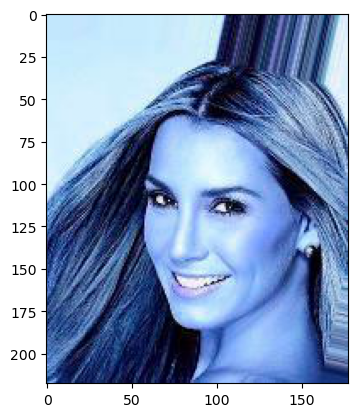

In [26]:
# load images
def tensor_to_image(x, permute=True):
    if len(x.shape) == 4:
        x = x[0]  # take first image in batch
    if permute:
        x = x.permute(1, 2, 0)
    x = x.detach().numpy()
    x = np.clip(x, 0, 1)  # clip image to valid color range
    return x


# load images
all_images = load_dataset()
dataloader = DataLoader(all_images, batch_size=2, shuffle=True)

# display first image
image_batch = next(iter(dataloader))
plt.imshow(tensor_to_image(image_batch[0]))
plt.show()

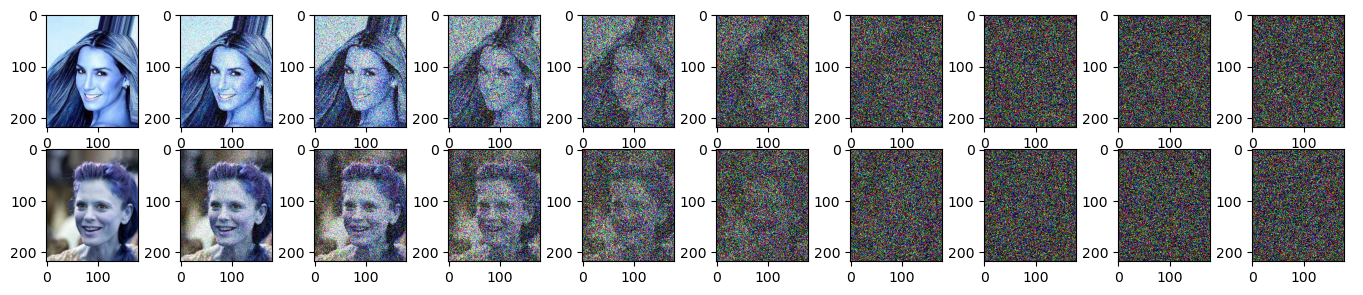

In [30]:
# test forward diffusion on a batch of images
num_display_steps = 10  # how many progress steps to display
T = 50
schedule = Schedule(beta_1, beta_T, T)
ddpm = DDPM(schedule)
x_t = image_batch

# display diffusion process
step_size = T // num_display_steps
grid_width = num_display_steps  # one column for each progress step
grid_height = image_batch.shape[0]  # one row for each image in the batch
plt.figure(figsize=(grid_width * 1.7, grid_height * 1.6))
plt.axis("off")
assert num_display_steps < 30, "Are you sure you want to display that many images?"
for t in range(T):
    x_t, noise = ddpm.forward_diffusion(x_t, t)
    if t % step_size == 0:
        col = t // step_size + 1
        for i in range(grid_height):
            plt.subplot(grid_height, grid_width, i * grid_width + col)
            plt.imshow(tensor_to_image(x_t[i]))

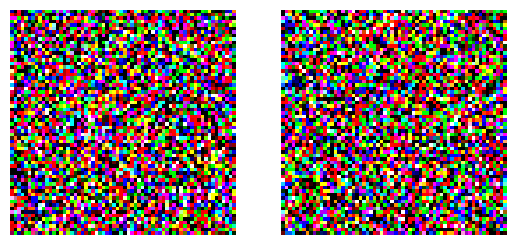

In [31]:
# test image generation on a batch of images
num_images = 2
shape = (3, 64, 64)
generated_image = ddpm.generate_images(shape, num_images)

for i in range(num_images):
    plt.subplot(1, num_images, i + 1)
    plt.axis("off")
    plt.imshow(tensor_to_image(generated_image[i : i + 1]))

In [25]:
# test training loop